<a href="https://colab.research.google.com/github/sandhiyasudha/machine-learning-project-sandhiya/blob/main/5b_sandhiya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student_placement_career_success_dataset.csv to student_placement_career_success_dataset.csv


Cluster Means:
[[ 0.33584297  0.11539335  0.04616631  0.02785185  1.29553581  0.05666494]
 [ 0.12696435  0.0326646   0.38772842  0.52121916  0.02272698  0.2812121 ]
 [-0.20757651 -0.062612   -0.32280466 -0.42307705 -0.42956235 -0.24148721]]

Number of students in each cluster:
Cluster 1 : 3765
Cluster 2 : 8613
Cluster 3 : 12622


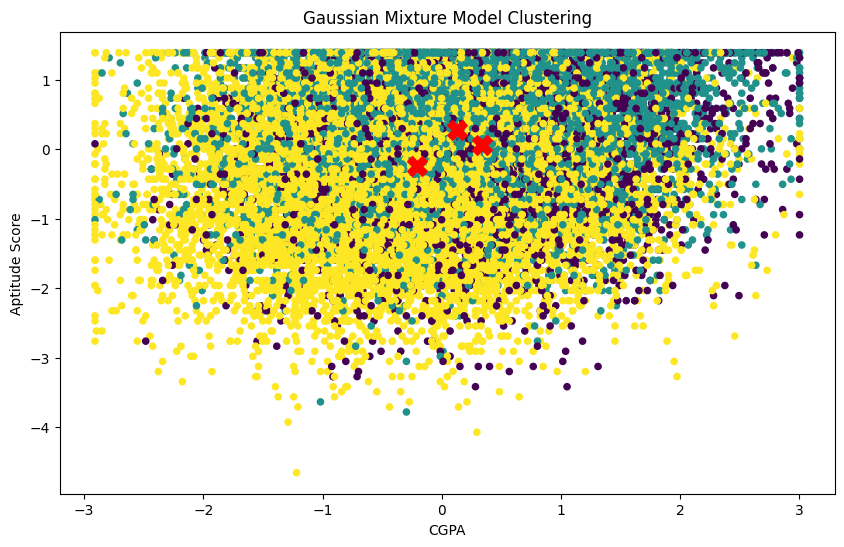

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Load dataset
data = pd.read_csv("student_placement_career_success_dataset.csv")

# Select career-related features
X = data[['cgpa',
          'DSA_problems_solved',
          'development_projects_count',
          'internships_completed',
          'communication_skills',
          'aptitude_score']]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define Gaussian Mixture Model
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

# Fit the GMM model
gmm.fit(X_scaled)

# Predict clusters
clusters = gmm.predict(X_scaled)

# Display cluster information
print("Cluster Means:")
print(gmm.means_)

print("\nNumber of students in each cluster:")
for i in range(3):
    print("Cluster", i + 1, ":", np.sum(clusters == i))

# Plot GMM results using CGPA and Aptitude Score
plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 5],
    c=clusters,
    cmap='viridis',
    marker='o',
    s=20
)

# Plot cluster centers
plt.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 5],
    c='red',
    marker='X',
    s=200
)

plt.title('Gaussian Mixture Model Clustering')
plt.xlabel('CGPA')
plt.ylabel('Aptitude Score')
plt.show()